<a href="https://colab.research.google.com/github/Sidhartht1607/Food-Vision-101-Class-Food-Image-Classifier/blob/main/notebook65d9425c3d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Introduction to convoluton neural networks.
- pizza ans steak classification

In [ ]:
import zipfile

!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

zip_ref = zipfile.ZipFile("pizza_steak.zip")
zip_ref.extractall()
zip_ref.close()

--2026-04-17 06:40:58--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 172.253.117.207, 142.250.99.207, 142.250.107.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.253.117.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M   130MB/s    in 0.8s    

2026-04-17 06:40:59 (130 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]



#Inspect the data (become one with the data)

A very crucial step in ML project is to become one with the data. This usually means visualizing many samples in your data.

In [ ]:
!ls pizza_steak

test  train


In [ ]:
!ls pizza_steak/train/

pizza  steak


In [ ]:
!ls pizza_steak/train/steak

1000205.jpg  1647351.jpg  2238681.jpg  2824680.jpg  3375959.jpg  417368.jpg
100135.jpg   1650002.jpg  2238802.jpg  2825100.jpg  3381560.jpg  4176.jpg
101312.jpg   165639.jpg   2254705.jpg  2826987.jpg  3382936.jpg  42125.jpg
1021458.jpg  1658186.jpg  225990.jpg   2832499.jpg  3386119.jpg  421476.jpg
1032846.jpg  1658443.jpg  2260231.jpg  2832960.jpg  3388717.jpg  421561.jpg
10380.jpg    165964.jpg   2268692.jpg  285045.jpg   3389138.jpg  438871.jpg
1049459.jpg  167069.jpg   2271133.jpg  285147.jpg   3393547.jpg  43924.jpg
1053665.jpg  1675632.jpg  227576.jpg   2855315.jpg  3393688.jpg  440188.jpg
1068516.jpg  1678108.jpg  2283057.jpg  2856066.jpg  3396589.jpg  442757.jpg
1068975.jpg  168006.jpg   2286639.jpg  2859933.jpg  339891.jpg	 443210.jpg
1081258.jpg  1682496.jpg  2287136.jpg  286219.jpg   3417789.jpg  444064.jpg
1090122.jpg  1684438.jpg  2291292.jpg  2862562.jpg  3425047.jpg  444709.jpg
1093966.jpg  168775.jpg   229323.jpg   2865730.jpg  3434983.jpg  447557.jpg
1098844.jpg  1697

In [ ]:
import os

#walk through pizza steak drectory and list number of files

for dirpath, dirnames, filenames in os.walk("pizza_steak"):
  print(f"There are {len(dirnames)} in directories and {len(filenames)} images in {dirpath}")

There are 2 in directories and 0 images in pizza_steak
There are 2 in directories and 0 images in pizza_steak/train
There are 0 in directories and 750 images in pizza_steak/train/steak
There are 0 in directories and 750 images in pizza_steak/train/pizza
There are 2 in directories and 0 images in pizza_steak/test
There are 0 in directories and 250 images in pizza_steak/test/steak
There are 0 in directories and 250 images in pizza_steak/test/pizza


In [ ]:
#Another way to find the images in a file.
num_steak_images_train = len(os.listdir("pizza_steak/train/steak"))
num_steak_images_train

750

#To visualize our images Lets get the classnames programmatically


In [ ]:
#get classnames programmatically
import pathlib
import numpy as np

data_dir=pathlib.Path('pizza_steak/train')
class_names=np.array(sorted([item.name for item in data_dir.glob('*')] ))
print(class_names)

['pizza' 'steak']


In [ ]:
data_dir.glob('*')

<generator object Path.glob at 0x79680098e020>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir,target_class):
  #Set up target directory (to view images)
  target_folder=target_dir+'/'+target_class
  #Get a random image path
  random_image_path=random.sample(os.listdir(target_folder),1)
  print(random_image_path)

  #Read in the image and plot it using matplotlib
  img=mpimg.imread(target_folder+'/'+random_image_path[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis('off')

  print(f"Image shape: {img.shape}")
  return img



['3512070.jpg']
Image shape: (512, 512, 3)


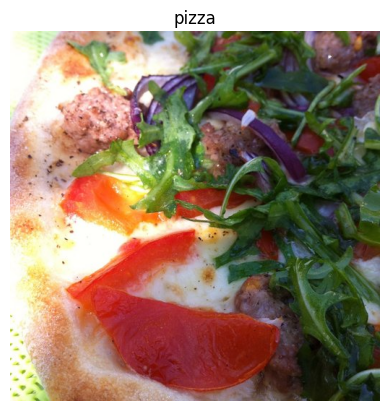

In [ ]:
img=view_random_image(target_dir='pizza_steak/train',target_class='pizza')

array([[[255, 254, 252],
        [255, 254, 250],
        [255, 254, 250],
        ...,
        [105,  72,  83],
        [100,  69,  84],
        [ 95,  67,  81]],

       [[255, 254, 252],
        [255, 254, 250],
        [255, 254, 250],
        ...,
        [104,  72,  83],
        [100,  72,  84],
        [ 96,  72,  85]],

       [[255, 254, 252],
        [255, 254, 250],
        [255, 254, 250],
        ...,
        [101,  74,  83],
        [ 99,  78,  87],
        [ 97,  80,  88]],

       ...,

       [[255, 255, 246],
        [255, 255, 243],
        [255, 255, 233],
        ...,
        [ 16,  29,   3],
        [ 19,  31,   7],
        [ 20,  32,   8]],

       [[253, 254, 240],
        [253, 254, 238],
        [254, 253, 232],
        ...,
        [ 18,  31,   3],
        [ 19,  32,   6],
        [ 19,  33,   7]],

       [[253, 254, 238],
        [255, 255, 239],
        [255, 255, 237],
        ...,
        [ 19,  32,   2],
        [ 18,  32,   6],
        [ 18,  32,   6]]], dtype=uint8)
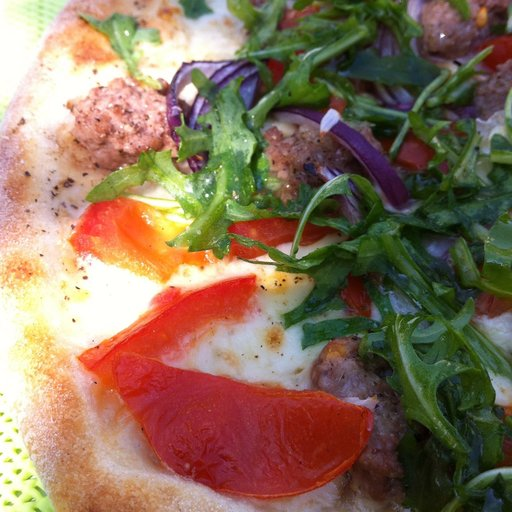

In [ ]:
img

In [ ]:
import tensorflow as tf

tf.constant(img)

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[255, 254, 252],
        [255, 254, 250],
        [255, 254, 250],
        ...,
        [105,  72,  83],
        [100,  69,  84],
        [ 95,  67,  81]],

       [[255, 254, 252],
        [255, 254, 250],
        [255, 254, 250],
        ...,
        [104,  72,  83],
        [100,  72,  84],
        [ 96,  72,  85]],

       [[255, 254, 252],
        [255, 254, 250],
        [255, 254, 250],
        ...,
        [101,  74,  83],
        [ 99,  78,  87],
        [ 97,  80,  88]],

       ...,

       [[255, 255, 246],
        [255, 255, 243],
        [255, 255, 233],
        ...,
        [ 16,  29,   3],
        [ 19,  31,   7],
        [ 20,  32,   8]],

       [[253, 254, 240],
        [253, 254, 238],
        [254, 253, 232],
        ...,
        [ 18,  31,   3],
        [ 19,  32,   6],
        [ 19,  33,   7]],

       [[253, 254, 238],
        [255, 255, 239],
        [255, 255, 237],
        ...,
        [ 19,  32,   

## An end-to-end example

Let's build a convolutional neural network to find patterns in our images, more specificaally we need a way to:

* Load our images
* Preproccessing images
* Build a CNN to find patterns in images
* Compile CNN
* Fit the CNN to our training data

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
#set random seed
tf.random.set_seed(42)

#preprocessing data (get all the pixels )
train_data_gen=ImageDataGenerator(rescale=1./255)
valid_data_gen=ImageDataGenerator(rescale=1./255)

#train data directory
train_dir='/content/pizza_steak/train'
test_dir='/content/pizza_steak/test'

#add data
train_data = train_data_gen.flow_from_directory(directory=train_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               class_mode='binary',
                                               seed=42)

valid_data = valid_data_gen.flow_from_directory(directory=test_dir,
                                                batch_size=32,
                                                target_size=(224,224),
                                                class_mode='binary',
                                                seed=42)

model_1=tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                    kernel_size=3,
                    activation='relu',
                    input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(10,3,activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2, padding='valid'),
    tf.keras.layers.Conv2D(10,3,activation='relu'),
    tf.keras.layers.Conv2D(10,2,activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2, padding='valid'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1,activation='sigmoid')

])

#Compile the model
model_1.compile(loss='binary_crossentropy',
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

#Fit the model
history_1=model_1.fit(train_data,
                      epochs=5,
                      steps_per_epoch=len(train_data),
                      validation_data=valid_data,
                      validation_steps=len(valid_data)
                      )



Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 289ms/step - accuracy: 0.7147 - loss: 0.5533 - val_accuracy: 0.7920 - val_loss: 0.4491
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.7860 - loss: 0.4590 - val_accuracy: 0.8640 - val_loss: 0.3744
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - accuracy: 0.8180 - loss: 0.4018 - val_accuracy: 0.8340 - val_loss: 0.3943
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - accuracy: 0.8427 - loss: 0.3671 - val_accuracy: 0.8620 - val_loss: 0.3433
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - accuracy: 0.8513 - loss: 0.3396 - val_accuracy: 0.8560 - val_loss: 0.3572


In [ ]:
len(train_data)

47

In [ ]:
1500/32

46.875

# PART 2: Food Vision Full — Transfer Learning on Food101

In [ ]:
import os
SAVE_DIR = '/kaggle/working/food_vision_full'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory: {SAVE_DIR}")

Save directory: /kaggle/working/food_vision_full


In [ ]:
import tensorflow as tf
from tensorflow.keras import mixed_precision, layers
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix

mixed_precision.set_global_policy('mixed_float16')
print("Compute policy:", mixed_precision.global_policy().name)
print("GPUs detected:", [g.name for g in tf.config.list_physical_devices('GPU')])

2026-05-28 16:23:10.272317: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779985390.475235      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779985390.529930      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779985390.983269      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779985390.983315      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779985390.983317      58 computation_placer.cc:177] computation placer alr

Compute policy: mixed_float16
GPUs detected: ['/physical_device:GPU:0']


In [ ]:
(train_ds, test_ds), meta = tfds.load(
    'food101',
    split=['train', 'validation'],
    as_supervised=True,
    with_info=True,
    shuffle_files=True
)

CLASS_NAMES = meta.features['label'].names
N_CLASSES = len(CLASS_NAMES)
N_TRAIN = meta.splits['train'].num_examples
N_TEST  = meta.splits['validation'].num_examples

print(f"{N_CLASSES} classes | {N_TRAIN:,} train | {N_TEST:,} test images")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.M1WINW_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.M1WINW_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.
101 classes | 75,750 train | 25,250 test images


I0000 00:00:1779986044.770668      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [ ]:
IMG_SIZE   = 260
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

def preprocess(img, label):
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    img = tf.image.random_crop(
        tf.image.resize_with_crop_or_pad(img, IMG_SIZE + 20, IMG_SIZE + 20),
        size=[IMG_SIZE, IMG_SIZE, 3]
    )
    return img, label

train_pipeline = (
    train_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment,    num_parallel_calls=AUTOTUNE)
    .shuffle(buffer_size=2000, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_pipeline = (
    test_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [ ]:
def build_model(num_classes, img_size, trainable_base=False):
    base = tf.keras.applications.EfficientNetB2(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size, img_size, 3)
    )
    base.trainable = trainable_base

    inputs  = layers.Input(shape=(img_size, img_size, 3))
    # Manually apply EfficientNet preprocessing (scales [0,255] → model's expected range)
    x       = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x       = base(x, training=trainable_base)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(512, activation='relu')(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    return tf.keras.Model(inputs, outputs)

model_2 = build_model(N_CLASSES, IMG_SIZE, trainable_base=False)

total     = sum(np.prod(w.shape) for w in model_2.weights)
trainable = sum(np.prod(w.shape) for w in model_2.trainable_weights)
print(f"Total params: {total:,} | Trainable: {trainable:,} ({trainable/total*100:.1f}%)")

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Total params: 8,547,422.0 | Trainable: 776,037 (9.1%)


In [ ]:
import os
os.remove('/content/drive/MyDrive/food_vision_full/feature_extraction.keras')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/food_vision_full/feature_extraction.keras'

In [ ]:
STEPS_PER_EPOCH = N_TRAIN // BATCH_SIZE

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=STEPS_PER_EPOCH * 5
)

model_2.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
    metrics=['accuracy']
)

callbacks_fe = [
    tf.keras.callbacks.ModelCheckpoint(
        f'{SAVE_DIR}/feature_extraction.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, restore_best_weights=True
    )
]

print("Phase 1: Feature Extraction (base frozen)")
history_fe = model_2.fit(
    train_pipeline,
    epochs=5,
    validation_data=test_pipeline,
    callbacks=callbacks_fe
)

Phase 1: Feature Extraction (base frozen)
Epoch 1/5


I0000 00:00:1779987900.702243     147 service.cc:152] XLA service 0x28ac3d50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779987900.702289     147 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779987905.177950     147 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779987945.464379     147 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.4109 - loss: 2.6761
Epoch 1: val_accuracy improved from None to 0.73299, saving model to /kaggle/working/food_vision_full/feature_extraction.keras

Epoch 1: finished saving model to /kaggle/working/food_vision_full/feature_extraction.keras
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 369s 121ms/step - accuracy: 0.5044 - loss: 2.0951 - val_accuracy: 0.7330 - val_loss: 0.9812
Epoch 2/5
2367/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6223 - loss: 1.4788
Epoch 2: val_accuracy improved from 0.73299 to 0.77572, saving model to /kaggle/working/food_vision_full/feature_extraction.keras

Epoch 2: finished saving model to /kaggle/working/food_vision_full/feature_extraction.keras
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 183s 76ms/step - accuracy: 0.6316 - loss: 1.4373 - val_accuracy: 0.7757 - val_loss: 0.8187
Epoch 3/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6788 - loss: 1.2209
Epoch 3: val_accuracy improved from 0.77572 to 0.80345, sa

In [ ]:
# Unfreeze top 30 layers
base_model = model_2.layers[1]
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

unfrozen = sum(1 for l in base_model.layers if l.trainable)
print(f"Unfrozen base layers: {unfrozen} / {len(base_model.layers)}")

ft_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-5,
    decay_steps=STEPS_PER_EPOCH * 10
)

model_2.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.AdamW(learning_rate=ft_lr, weight_decay=1e-5),
    metrics=['accuracy']
)

callbacks_ft = [
    tf.keras.callbacks.ModelCheckpoint(
        '/content/fine_tuned.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, verbose=1
    )
]

print("Phase 2: Fine-Tuning (top 30 layers unfrozen)")
history_ft = model_2.fit(
    train_pipeline,
    epochs=15,
    validation_data=test_pipeline,
    callbacks=callbacks_ft,
    initial_epoch=len(history_fe.epoch)
)

Unfrozen base layers: 30 / 340
Phase 2: Fine-Tuning (top 30 layers unfrozen)
Epoch 6/15
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7837 - loss: 0.7911
Epoch 6: val_accuracy improved from None to 0.82685, saving model to /content/fine_tuned.keras

Epoch 6: finished saving model to /content/fine_tuned.keras
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 313s 106ms/step - accuracy: 0.7841 - loss: 0.7840 - val_accuracy: 0.8269 - val_loss: 0.6315 - learning_rate: 4.8775e-05
Epoch 7/15
2367/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7869 - loss: 0.7551
Epoch 7: val_accuracy improved from 0.82685 to 0.82915, saving model to /content/fine_tuned.keras

Epoch 7: finished saving model to /content/fine_tuned.keras
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 185s 76ms/step - accuracy: 0.7892 - loss: 0.7493 - val_accuracy: 0.8291 - val_loss: 0.6265 - learning_rate: 4.5223e-05
Epoch 8/15
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7971 - loss: 0.7240
Epoch 8: val_accuracy did not improve fr

In [ ]:
# Collect ground truth and predictions
y_true, y_pred = [], []
for images, labels in test_pipeline:
    preds = model_2.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

test_acc    = np.mean(y_true == y_pred)
f1_macro    = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

# Published baselines
BASELINES = {
    'Food101 Paper (Bossard et al., 2014)': 0.505,
    'DeepFood (Liu et al., 2016)':          0.774,
    'Our Model (EfficientNetB2)':           test_acc
}

print("\n" + "="*55)
print(f"{'Model':<40} {'Top-1 Acc':>10}")
print("="*55)
for name, acc in BASELINES.items():
    marker = " ✓ OURS" if "Our" in name else ""
    print(f"{name:<40} {acc*100:>9.1f}%{marker}")
print("="*55)
print(f"\nF1 Macro:    {f1_macro*100:.2f}%")
print(f"F1 Weighted: {f1_weighted*100:.2f}%")
print(f"vs DeepFood: {(test_acc - 0.774)*100:+.2f}%")


Model                                     Top-1 Acc
Food101 Paper (Bossard et al., 2014)          50.5%
DeepFood (Liu et al., 2016)                   77.4%
Our Model (EfficientNetB2)                    83.2% ✓ OURS

F1 Macro:    83.13%
F1 Weighted: 83.13%
vs DeepFood: +5.83%


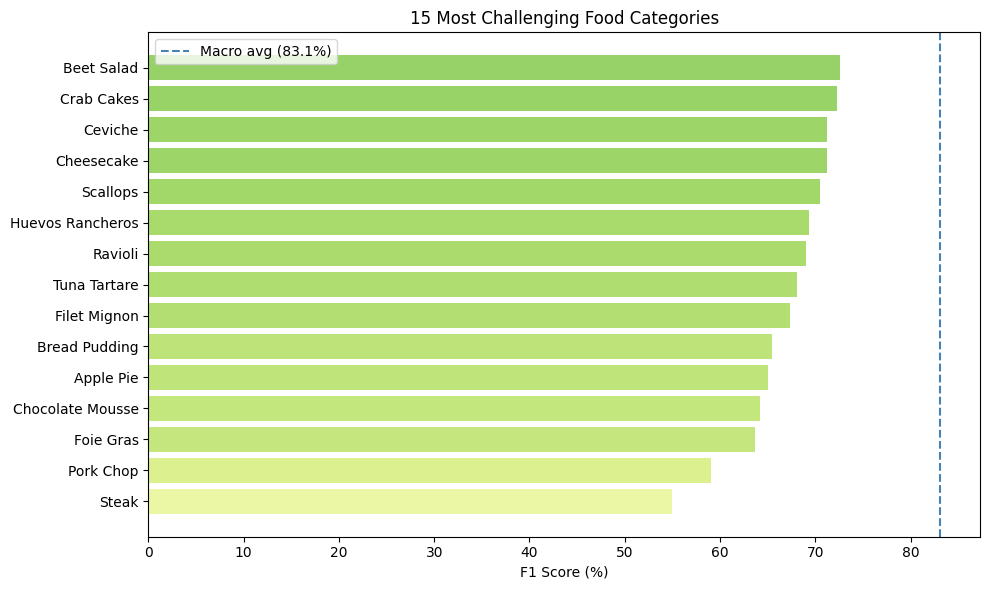

In [ ]:
per_class_f1 = f1_score(y_true, y_pred, average=None)
sorted_idx   = np.argsort(per_class_f1)[:15]  # 15 worst

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    [CLASS_NAMES[i].replace('_', ' ').title() for i in sorted_idx],
    per_class_f1[sorted_idx] * 100,
    color=plt.cm.RdYlGn(per_class_f1[sorted_idx])
)
ax.axvline(f1_macro * 100, color='steelblue', linestyle='--', label=f'Macro avg ({f1_macro*100:.1f}%)')
ax.set_xlabel('F1 Score (%)')
ax.set_title('15 Most Challenging Food Categories')
ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/per_class_f1.png', dpi=150)
plt.show()

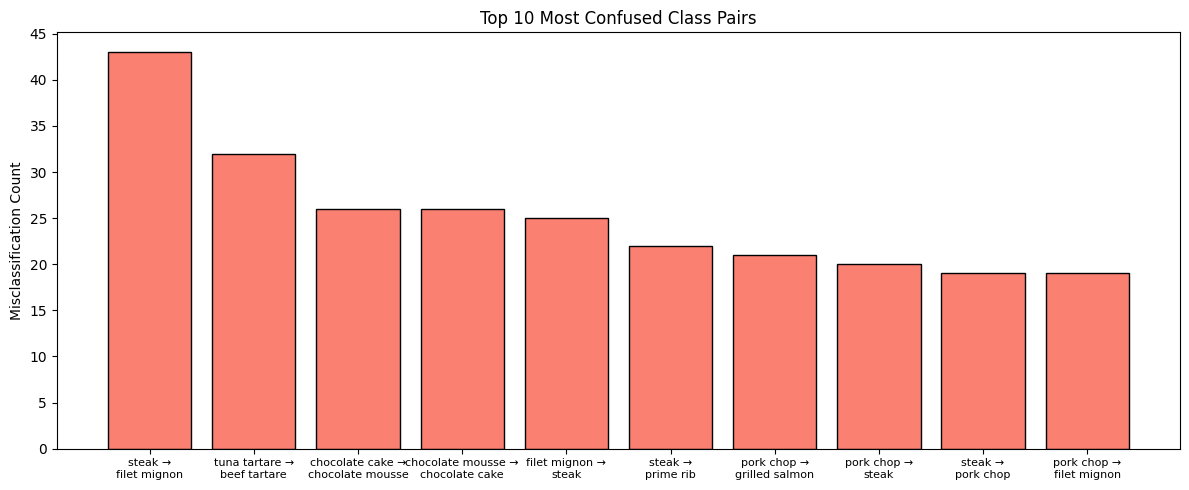

In [ ]:
cm = confusion_matrix(y_true, y_pred)
np.fill_diagonal(cm, 0)  # remove correct predictions

# Find top 10 confused pairs
flat_idx  = np.argsort(cm.flatten())[::-1][:10]
row_idx, col_idx = np.unravel_index(flat_idx, cm.shape)

pairs      = [(CLASS_NAMES[r], CLASS_NAMES[c], cm[r, c]) for r, c in zip(row_idx, col_idx)]
pair_labels = [f"{a.replace('_',' ')} →\n{b.replace('_',' ')}" for a, b, _ in pairs]
pair_counts = [n for _, _, n in pairs]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(pair_labels, pair_counts, color='salmon', edgecolor='black')
ax.set_ylabel('Misclassification Count')
ax.set_title('Top 10 Most Confused Class Pairs')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.xticks(fontsize=8)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confused_pairs.png', dpi=150)
plt.show()

In [ ]:
model_2.save('/kaggle/working/food_vision_full/fine_tuned_final.keras')

In [ ]:
callbacks_ft[0] = tf.keras.callbacks.ModelCheckpoint(
    '/kaggle/working/food_vision_full/fine_tuned.keras',
    monitor='val_accuracy', save_best_only=True, verbose=1
)